<a href="https://colab.research.google.com/github/asuhconcentric-droid/cafe-sales-performance-analysis/blob/main/cafe_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ☕ Cafe Sales Performance Analysis

## Objective
This project analyzes transactional sales data from a cafe to uncover revenue patterns,
classify menu performance, and generate actionable business recommendations.
It demonstrates a full analytics workflow: from raw, messy data to strategic insight.

**Skills demonstrated:** data cleaning, feature engineering, exploratory data analysis,
custom classification logic, time-series analysis, and data visualization.

---

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("dirty_cafe_sales.csv")

# Check first 5 rows of dataset
print(df.head())

# Check datatypes of each column
print(df.dtypes)

df.count()

  Transaction ID    Item Quantity Price Per Unit Total Spent  Payment Method  \
0    TXN_1961373  Coffee        2            2.0         4.0     Credit Card   
1    TXN_4977031    Cake        4            3.0        12.0            Cash   
2    TXN_4271903  Cookie        4            1.0       ERROR     Credit Card   
3    TXN_7034554   Salad        2            5.0        10.0         UNKNOWN   
4    TXN_3160411  Coffee        2            2.0         4.0  Digital Wallet   

   Location Transaction Date  
0  Takeaway       2023-09-08  
1  In-store       2023-05-16  
2  In-store       2023-07-19  
3   UNKNOWN       2023-04-27  
4  In-store       2023-06-11  
Transaction ID      object
Item                object
Quantity            object
Price Per Unit      object
Total Spent         object
Payment Method      object
Location            object
Transaction Date    object
dtype: object


,0
Transaction ID,10000
Item,9667
Quantity,9862
Price Per Unit,9821
Total Spent,9827
Payment Method,7421
Location,6735
Transaction Date,9841


## 🧹 Data Cleaning
The raw dataset contained missing values, non-numeric entries, and inconsistent categorical labels.
The steps below standardize the data before analysis.

In [24]:
# Drop unnecessary column
df.drop(["Transaction ID"], axis=1, inplace=True)

# Convert numeric columns
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")
df["Quantity"] = pd.to_numeric(df['Quantity'], errors="coerce")

# Convert date column
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

# Recheck column datatypes after converting
print(df.dtypes)

# Standardize categorical columns to "UNKNOWN"
category_columns = ["Item", "Payment Method", "Location"]
df[category_columns] = df[category_columns].replace(["", "ERROR"], "UNKNOWN")
df[category_columns] = df[category_columns].fillna("UNKNOWN")

# Recalculate missing Total Spent
mask_total = df["Total Spent"].isna()
df.loc[mask_total, "Total Spent"] = (
    df.loc[mask_total, "Price Per Unit"] * df.loc[mask_total, "Quantity"]
)

# Recalculate missing Quantity
mask_quantity = df["Quantity"].isna() & df["Price Per Unit"].notna() & df["Total Spent"].notna()
df.loc[mask_quantity, "Quantity"] = df.loc[mask_quantity, "Total Spent"] / df.loc[mask_quantity, "Price Per Unit"]

# Recalculate missing Price Per Unit
mask_price = df["Price Per Unit"].isna() & df["Quantity"].notna() & df["Total Spent"].notna()
df.loc[mask_price, "Price Per Unit"] = df.loc[mask_price, "Total Spent"] / df.loc[mask_price, "Quantity"]

# Identify prices tied to only one item
price_item_counts = df[df["Item"] != "UNKNOWN"].groupby("Price Per Unit")["Item"].nunique()
safe_prices = price_item_counts[price_item_counts == 1].index
price_to_item = df[df["Price Per Unit"].isin(safe_prices) & (df["Item"] != "UNKNOWN")].drop_duplicates("Price Per Unit")
price_map = dict(zip(price_to_item["Price Per Unit"], price_to_item["Item"]))

# Fill UNKNOWN Items safely
mask_unknown = (df["Item"] == "UNKNOWN") & (df["Price Per Unit"].isin(safe_prices))
df.loc[mask_unknown, "Item"] = df.loc[mask_unknown, "Price Per Unit"].map(price_map)

Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object


## 🗓️ Data Preparation & Feature Engineering
New time-based features are created to support seasonal and weekly analysis.

In [25]:
df["Month"] = df["Transaction Date"].dt.month_name()
df["DayOfWeek"] = df["Transaction Date"].dt.day_name()
df["YearMonth"] = df["Transaction Date"].dt.to_period("M")

months_order = ["January", "February", "March", "April", "May", "June",
                "July", "August", "September", "October", "November", "December"]

## 🔍 Exploratory Data Analysis
The following section explores revenue and sales volume across items, time periods,
payment methods, and locations to identify patterns and surface business opportunities.

In [26]:
# Revenue by Item
revenue_by_item = df.groupby("Item", as_index=False)["Total Spent"].sum().sort_values(by="Total Spent", ascending=False)
print(revenue_by_item)

# Quantity by Item
quantity_by_item = df.groupby("Item", as_index=False)["Quantity"].sum().sort_values(by="Quantity", ascending=False)
print(quantity_by_item)

# Revenue by Month
revenue_by_month = df.groupby("YearMonth", as_index=False)["Total Spent"].sum().sort_values(by="YearMonth")
revenue_by_month["YearMonth"] = revenue_by_month["YearMonth"].dt.to_timestamp()
print(revenue_by_month)

# Revenue by Payment Method
revenue_by_payment_method = df.groupby("Payment Method", as_index=False)["Total Spent"].sum().sort_values(by="Total Spent", ascending=False)
print(revenue_by_payment_method)

# Revenue by Location
revenue_by_location = df.groupby("Location", as_index=False)["Total Spent"].sum().sort_values(by="Total Spent", ascending=False)
print(revenue_by_location)

       Item  Total Spent
4     Salad      19070.0
5  Sandwich      13664.0
6  Smoothie      13320.0
3     Juice      10509.0
0      Cake      10395.0
1    Coffee       7798.0
7       Tea       5466.0
8   UNKNOWN       5141.0
2    Cookie       3589.0
       Item  Quantity
1    Coffee    3902.0
4     Salad    3818.0
7       Tea    3635.0
2    Cookie    3594.0
3     Juice    3505.0
0      Cake    3462.0
5  Sandwich    3424.0
6  Smoothie    3330.0
8   UNKNOWN    1471.0
    YearMonth  Total Spent
0  2023-01-01       7242.0
1  2023-02-01       6633.5
2  2023-03-01       7214.5
3  2023-04-01       7168.0
4  2023-05-01       6941.5
5  2023-06-01       7350.0
6  2023-07-01       6877.5
7  2023-08-01       7077.5
8  2023-09-01       6846.0
9  2023-10-01       7302.0
10 2023-11-01       6957.0
11 2023-12-01       7177.0
   Payment Method  Total Spent
3         UNKNOWN      27775.0
1     Credit Card      20427.0
2  Digital Wallet      20383.5
0            Cash      20366.5
   Location  Total Spent

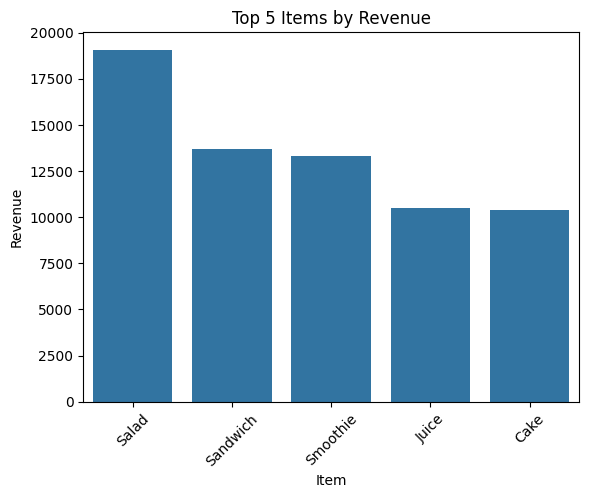

In [27]:
# Top 5 Items by Revenue
top_5_revenue = revenue_by_item.head()
sns.barplot(data=top_5_revenue, x="Item", y="Total Spent")
plt.ylabel("Revenue")
plt.title("Top 5 Items by Revenue")
plt.xticks(rotation=45)


plt.savefig("top_5_items_by_revenue.png", bbox_inches="tight", dpi=150)
plt.show()

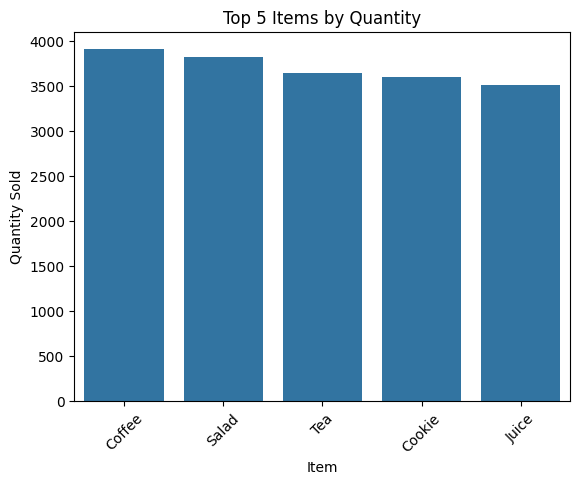

In [28]:
# Top 5 Items by Quantity Sold
top_5_quantity = quantity_by_item.head()
sns.barplot(data=top_5_quantity, x="Item", y="Quantity")
plt.ylabel("Quantity Sold")
plt.title("Top 5 Items by Quantity")
plt.xticks(rotation=45)
plt.show()

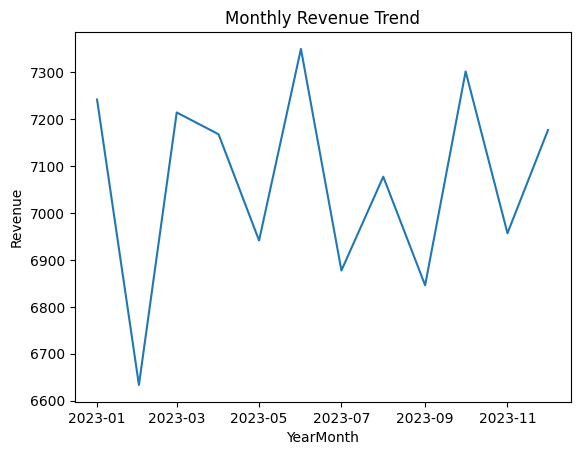

In [29]:
# Revenue Trend Over Time
sns.lineplot(data=revenue_by_month, x="YearMonth", y="Total Spent")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")

plt.savefig("monthly_revenue_trend.png", bbox_inches="tight", dpi=150)
plt.show()

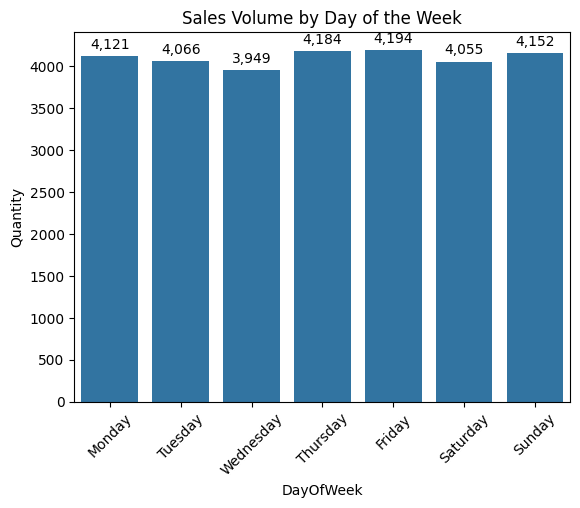

In [30]:
# Busiest Day of Week Analysis
sales_by_day = df.groupby("DayOfWeek", as_index=False)["Quantity"].sum()
sales_by_day["DayOfWeek"] = pd.Categorical(
    sales_by_day["DayOfWeek"],
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True
)
sales_by_day = sales_by_day.sort_values("DayOfWeek")
ax = sns.barplot(data=sales_by_day, x="DayOfWeek", y="Quantity")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3)
plt.title("Sales Volume by Day of the Week")
plt.xticks(rotation=45)
plt.show()

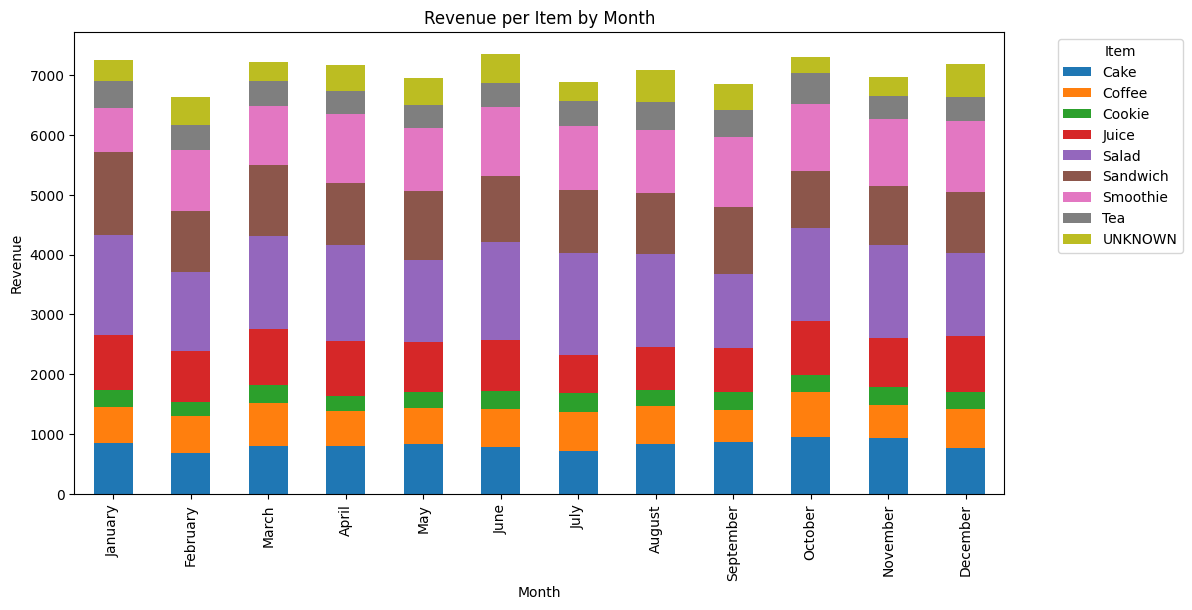

In [31]:
# Seasonal Item Revenue
monthly_item_revenue = df.groupby(["Month", "Item"])["Total Spent"].sum().unstack(fill_value=0)
monthly_item_revenue = monthly_item_revenue.reindex(months_order)
monthly_item_revenue.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Revenue per Item by Month")
plt.ylabel("Revenue")
plt.legend(title="Item", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## 🧩 Menu Performance Matrix
Each menu item is classified into one of four categories based on its total revenue
and quantity sold relative to the median:

| Category | Revenue | Volume |
|---|---|---|
| ⭐ Star | High | High |
| 💎 Premium | High | Low |
| 🚗 Traffic Driver | Low | High |
| ❌ Weak | Low | Low |

In [32]:
revenue_totals = df.groupby("Item")["Total Spent"].sum()
quantity_totals = df.groupby("Item")["Quantity"].sum()

rev_median = revenue_totals.median()
qty_median = quantity_totals.median()

performance_matrix = pd.DataFrame({
    "Revenue": revenue_totals,
    "Quantity": quantity_totals
})

def classify(row):
    if row["Revenue"] >= rev_median and row["Quantity"] >= qty_median:
        return "Star"          # High revenue, high volume
    elif row["Revenue"] >= rev_median and row["Quantity"] < qty_median:
        return "Premium"       # High revenue, low volume
    elif row["Revenue"] < rev_median and row["Quantity"] >= qty_median:
        return "Traffic Driver"  # Low revenue, high volume
    else:
        return "Weak"          # Low revenue, low volume

performance_matrix["Category"] = performance_matrix.apply(classify, axis=1)
performance_matrix

,Revenue,Quantity,Category
Item,,,
Cake,10395.0,3462.0,Premium
Coffee,7798.0,3902.0,Traffic Driver
Cookie,3589.0,3594.0,Traffic Driver
Juice,10509.0,3505.0,Star
Salad,19070.0,3818.0,Star
Sandwich,13664.0,3424.0,Premium
Smoothie,13320.0,3330.0,Premium
Tea,5466.0,3635.0,Traffic Driver
UNKNOWN,5141.0,1471.0,Weak


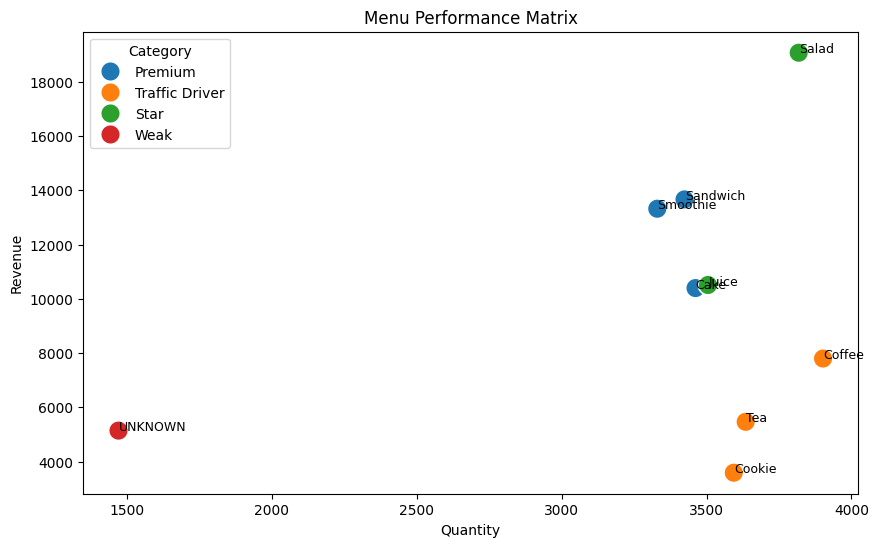

In [33]:
# Scatter Plot - Menu Performance Matrix
plt.figure(figsize=(10, 6))
sns.scatterplot(data=performance_matrix, x="Quantity", y="Revenue", hue="Category", s=200)
for item in performance_matrix.index:
    plt.text(performance_matrix.loc[item, "Quantity"] + 0.5,
             performance_matrix.loc[item, "Revenue"] + 0.5,
             item, fontsize=9)
plt.title("Menu Performance Matrix")

plt.savefig("menu_performance_matrix.png", bbox_inches="tight", dpi=150)
plt.show()

## 📅 Monthly Item Classification
The same Star / Premium / Traffic Driver / Weak classification is applied month-by-month
to track how each item's performance shifts across the year.

In [34]:
# Monthly Revenue per Item
monthly_revenue = (df.groupby(["Month", "Item"])["Total Spent"]
                   .sum().unstack(fill_value=0)
                   .reindex(months_order, fill_value=0))

# Monthly Quantity per Item
monthly_quantity = (df.groupby(["Month", "Item"])["Quantity"]
                    .sum().unstack(fill_value=0)
                    .reindex(months_order, fill_value=0))

In [35]:
# Define function to classify items in each month
def classify_month(row_rev, row_qty):
    categories = []
    rev_median = row_rev.median()
    qty_median = row_qty.median()
    for item in row_rev.index:
        rev = row_rev[item]
        qty = row_qty[item]
        if rev >= rev_median and qty >= qty_median:
            categories.append("Star")
        elif rev >= rev_median and qty < qty_median:
            categories.append("Premium")
        elif rev < rev_median and qty >= qty_median:
            categories.append("Traffic Driver")
        else:
            categories.append("Weak")
    return pd.Series(categories, index=row_rev.index)

# Build monthly performance matrix
monthly_matrix = pd.concat([
    pd.DataFrame(
        [classify_month(monthly_revenue.loc[month], monthly_quantity.loc[month])],
        index=[month]
    )
    for month in months_order
])
monthly_matrix

Item,Cake,Coffee,Cookie,Juice,Salad,Sandwich,Smoothie,Tea,UNKNOWN
January,Premium,Traffic Driver,Weak,Star,Star,Star,Premium,Traffic Driver,Weak
February,Premium,Traffic Driver,Weak,Star,Star,Star,Premium,Traffic Driver,Weak
March,Premium,Traffic Driver,Traffic Driver,Star,Star,Star,Premium,Weak,Weak
April,Star,Traffic Driver,Weak,Star,Star,Premium,Star,Weak,Weak
May,Star,Traffic Driver,Traffic Driver,Star,Premium,Star,Premium,Weak,Weak
June,Premium,Traffic Driver,Traffic Driver,Star,Star,Premium,Star,Weak,Weak
July,Premium,Star,Traffic Driver,Weak,Star,Star,Star,Traffic Driver,Weak
August,Star,Traffic Driver,Traffic Driver,Premium,Star,Premium,Premium,Traffic Driver,Weak
September,Star,Weak,Traffic Driver,Premium,Premium,Star,Star,Traffic Driver,Weak
October,Star,Traffic Driver,Weak,Star,Star,Premium,Premium,Traffic Driver,Weak


## 📊 Key Findings & Business Insights

---

### ⭐ Overall Revenue Drivers
**Salad** consistently generated the highest total revenue across the dataset, classified as a **Star** item
in most months. In 2 months it shifted to **Premium**, indicating sustained high revenue but a relative dip
in volume — still a strong anchor product overall.

---

### 🚗 High-Volume, Lower-Revenue Items (Traffic Drivers)
**Coffee** showed high sales volume but comparatively lower total revenue, frequently appearing in the
**Traffic Driver** category.

**Business implication:** Coffee brings customers in — this creates an opportunity to:
- Bundle coffee with higher-margin items
- Upsell premium variations (e.g., specialty lattes)
- Offer combo promotions to increase average order value

---

### 💎 Strong but Variable Mid-Tier Performers
**Cake, Sandwich, and Smoothie** frequently alternate between **Star** and **Premium** classifications across months:
- When classified as **Star** → high revenue *and* high volume
- When classified as **Premium** → strong revenue, but relatively lower volume

**What this suggests:**
- These items likely carry higher price points
- Demand may be seasonal or event-driven
- Small changes in volume can shift their classification

**Business implication:** These products are high-revenue contributors with fluctuating demand.
Targeted promotions could help stabilize them as consistent Star items.

---

### 🍵 Underperforming but High-Volume Items
**Tea and Cookie** frequently alternate between **Weak** and **Traffic Driver** categories.
Both rank among the top items by quantity sold, but contribute relatively low total revenue —
likely due to lower unit pricing.

**Opportunities:**
- **Bundling** — pair Tea or Cookie with higher-margin items to increase order value
- **Slight price optimization** — a small price increase may not reduce volume significantly
- **Product repositioning** — promote premium variations (e.g., specialty teas, upgraded desserts)

---

### 🥪 Low-Volume, High-Revenue Power
**Sandwich** alternates between **Star** and **Premium** and ranks **2nd in total revenue** despite moderate
order volume. This suggests strong per-unit profitability — a high-value product well-suited for
margin-focused strategies.

---

### 🧃 Strong but Slightly Volatile Performer
**Juice** is mostly classified as **Star** with some **Premium** months, ranking **4th in revenue** and
**5th in quantity** — a well-balanced performer overall.

However, it was classified as **Weak in July**, meaning both revenue and quantity dropped below median
that month. Possible explanations:
- Seasonal substitution (Smoothies may peak in summer)
- Demand shift driven by promotional timing

**Final thought:** Juice is a stable mid-to-high tier contributor with minor sensitivity to seasonal shifts.

---

## ✅ Summary & Recommendations

| Priority | Action | Target Item(s) |
|----------|--------|----------------|
| 🔴 High | Bundle with higher-margin items | Coffee, Tea, Cookie |
| 🟠 Medium | Targeted promotions to stabilize Star status | Cake, Sandwich, Smoothie |
| 🟡 Medium | Investigate July demand dip | Juice |
| 🟢 Low | Test small price increase | Tea, Cookie |

**Overall takeaway:** Salad is the clear anchor product. Coffee drives foot traffic but needs pairing
strategies to convert volume into revenue. Mid-tier items like Sandwich and Smoothie show strong
potential with the right promotional support.